# Producing temperature-dependant pendf files



In [1]:
import sandy
import importlib
importlib.reload(sandy)
import matplotlib.pyplot as plt
import numpy as np

# Define NJOY env variable
import os 
os.environ["NJOY"]="njoy"

In [2]:
N=10

In [3]:
# Download the U235 JEFF-3.3 file
lib_name = "jeff_33"
nucl = 922350
filename = f"{nucl}.{lib_name}"
endf6 = sandy.get_endf6_file(lib_name, 'xs', nucl)
endf6.to_file(filename)

In [4]:
# Set processing options for two temperatures
err_pendf = 0.1
pendf_kws = dict(
    verbose=False,
    err=err_pendf,
    minimal_processing=True,
    temperatures=[293., 600., 900., 1200., 1600., 2000.],
    acer=False,
    purr=False
    )

In [5]:
# Process the JEFF-3.3 file
from tempfile import TemporaryDirectory
from os.path import join
with TemporaryDirectory() as td:
    endf6file = join(td, "endf6_file")
    endf6.to_file(endf6file)
    outputs = sandy.njoy.process_neutron(
        endf6file,
        suffixes=[0],
        **pendf_kws,
        )
    pendfs = outputs["pendf"]


 njoy 2016.73  03Nov23                                       01/04/24 11:38:58
 *****************************************************************************

 moder...                                                                 0.0s

 reconr...                                                                0.2s

 ---message from rdf2bw---calculation of angular distribution not installed.

 broadr...                                                               66.1s
      293.0 deg                                                          66.3s
      600.0 deg                                                          75.0s
      900.0 deg                                                          84.7s
     1200.0 deg                                                          95.2s
     1600.0 deg                                                         106.6s
     2000.0 deg                                                         119.0s

 thermr...                                      

In [6]:
# Get Endf6 objects from a multi temperature pendf file
endfs  = sandy.get_pendf_endf(pendfs)

Entire file is repeated.


Generate 10 perturbations from the base endf file

In [7]:
err_errorr = 0.1
nubar=False
xs=True
chi=False
mubar = False
errorr_kws = dict(
    verbose=False,
    err=err_errorr,
    xs=xs,
    nubar=nubar,
    chi=chi,
    mubar=mubar,
    groupr_kws=dict(nubar=nubar, chi=chi, mubar=mubar, ign=2),
    errorr_kws=dict(ign=2)
    )
smps = endf6.get_perturbations(N, njoy_kws=errorr_kws)

INFO:  Zero or no temperature was requested, NJOY processing will stop after RECONR.
    If you want to process 0K cross sections use `temperature=0.1`.
    



 njoy 2016.73  03Nov23                                       01/04/24 11:44:27
 *****************************************************************************

 moder...                                                                 0.0s

 reconr...                                                                0.2s

 ---message from rdf2bw---calculation of angular distribution not installed.

 moder...                                                                 9.7s

 errorr...                                                               10.9s

 processing mat  9228
 ---------------------
  92-U -235 IRSN-CEA   EVAL-DEC14 IRSN-CEA DAM/DEN COLLAB.           

 covariances calculated for  8 reactions and  248 groups                 11.1s
                                                                         12.6s
 *****************************************************************************


INFO:  writing to file 'PERT_92235_MF33.xlsx'...


Perturb all temperatures. This will create an array of N (number of samples) dictionaries, where each dictionary has all temperatures in the original pendf perturbated by the same coefficient.

In [8]:
kws = dict()
perts = sandy.perturb_all_temps(endf6, endfs, smps, processes=12, **kws)

/mnt/disk4/malec/wims_perturbation/sandy-dev/lib/python3.10/site-packages/sandy-1.1-py3.10.egg/sandy/core/samples.py:206: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  for n, p in df.groupby(axis=1, level=self._columnsname):
/mnt/disk4/malec/wims_perturbation/sandy-dev/lib/python3.10/site-packages/sandy-1.1-py3.10.egg/sandy/core/xs.py:418: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  for mat, group in df.groupby("MAT", axis=1):
/mnt/disk4/malec/wims_perturbation/sandy-dev/lib/python3.10/site-packages/sandy-1.1-py3.10.egg/sandy/core/xs.py:418: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  for mat, group in df.groupby("MAT", axis=1):
/mnt/disk4/malec/wims_perturbation/sandy-dev/lib/python3.10/site-packages/sandy-1.1-py3.10.egg/sandy/core/xs.py:418: FutureWarning: DataFrame.groupby with axis=1 is de

Plot some results. We have plotted two perturbations at two temperatures. We can see that for each sample, we get all temperatures perturbated by the same ammount.

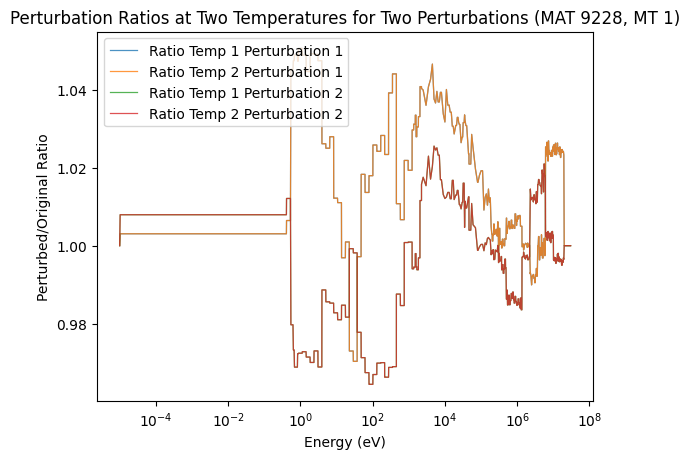

In [12]:
# Assuming 'perts' and 'endfs' are defined as before
temp_id1 = list(perts[0].keys())[0]  # First temperature
temp_id2 = list(perts[0].keys())[1]  # Second temperature

# Function to calculate ratio
def calculate_ratio(perturbed_xs, original_xs):
    # Ensure both dataframes have the same index
    common_index = perturbed_xs.index.intersection(original_xs.index)
    perturbed_cs = perturbed_xs.loc[common_index]
    original_cs = original_xs.loc[common_index]

    # Calculate ratio and handle division by zero
    with np.errstate(divide='ignore', invalid='ignore'):
        ratio = np.where(original_cs != 0, perturbed_cs / original_cs, np.nan)
    return ratio

# Create a figure for plotting
fig, ax = plt.subplots()

mat, mt = 9228, 18  # MAT and MT values

# Plotting function
def plot_perturbation_ratio(perturbation, label_suffix):
    original_endf6_temp1 = endfs[temp_id1]
    original_xs_temp1 = sandy.Xs.from_endf6(original_endf6_temp1).data[(mat, mt)]
    perturbed_endf6_temp1 = perts[perturbation][temp_id1]
    perturbed_xs_temp1 = sandy.Xs.from_endf6(perturbed_endf6_temp1).data[(mat, mt)]

    ratio_temp1 = calculate_ratio(perturbed_xs_temp1, original_xs_temp1)
    ax.plot(perturbed_xs_temp1.index, ratio_temp1, label=f"Ratio Temp {temp_id1} {label_suffix}", alpha=0.8, linewidth=0.9)

    original_endf6_temp2 = endfs[temp_id2]
    original_xs_temp2 = sandy.Xs.from_endf6(original_endf6_temp2).data[(mat, mt)]
    perturbed_endf6_temp2 = perts[perturbation][temp_id2]
    perturbed_xs_temp2 = sandy.Xs.from_endf6(perturbed_endf6_temp2).data[(mat, mt)]

    ratio_temp2 = calculate_ratio(perturbed_xs_temp2, original_xs_temp2)
    ax.plot(perturbed_xs_temp2.index, ratio_temp2, label=f"Ratio Temp {temp_id2} {label_suffix}", alpha=0.8, linewidth=0.9)

# Plot for the first perturbation
plot_perturbation_ratio(0, "Perturbation 1")

# Plot for the second perturbation
plot_perturbation_ratio(1, "Perturbation 2")

# Set plot title, labels, and legend
ax.set_title("Perturbation Ratios at Two Temperatures for Two Perturbations (MAT 9228, MT 1)")
ax.set_xlabel("Energy (eV)")
ax.set_ylabel("Perturbed/Original Ratio")
# log scale on x
ax.set_xscale('log')
ax.legend()

# Show the plot
plt.show()

In [10]:
# re-combine perturbed files and save to disk
for i, pert in enumerate(perts):
    joined = sandy.combine_pendf_sections(pert)
    with open(f"{nucl}_{i}.pendf", "w") as f:
        print(f"writing {nucl}_{i}.pendf")
        f.write(joined)

KeyboardInterrupt: 